# Initialization
Importing all that stuff and defining drawing routines. 

In [603]:
import numpy as np
import RandomTilings as RT
from RandomTilings._draw_dominos import draw_dominos
from RandomTilings._core import no_neighbor
from RandomTilingsTMP._draw_dominos import draw_dominos as draw_dominosTMP
from numba import jit,njit
from numba.typed import List 
from time import time
RT.config.set_hd_mode(1)
from mpmath import mp
mp.pretty = 1

weight_aztec = RT._weight_aztec.weight_aztec
def draw_Aztec(M,edge=0,paths=False,dots=False,rotated=True,coloring='standard',
                   show_gap=False,dpi=100,show_figure=False):
        edge = str(edge)
        return draw_dominos(M,False,edge,paths,dots,rotated,coloring,show_gap,dpi,show_figure)

def draw_AztecTMP(M,edge=0,paths=False,dots=False,rotated=True,coloring='standard',
                   show_gap=False,dpi=100,show_figure=False):
        edge = str(edge)
        return draw_dominosTMP(M,False,edge,paths,dots,rotated,coloring,show_gap,dpi,show_figure)

# Main Routine

In [695]:
def update_weight(W,E):
    M,N = W.shape
    M,N = M//2,N//2
    W1 = W.copy() + 1*(W==0)
    E1 = E.copy() + 1*(W==0)
    for m in range(M):
        for n in range(N):
            w,x,y,z     = W1[2*m,2*n],W1[2*m,2*n+1],W1[2*m+1,2*n],W1[2*m+1,2*n+1]
            ew,ex,ey,ez = E1[2*m,2*n],E1[2*m,2*n+1],E1[2*m+1,2*n],E1[2*m+1,2*n+1]

            Ixy = ex+ey
            Iwz = ew+ez
            if Ixy>Iwz:
                d           = w*z 
                w,x,y,z     = 1/w,y/d,x/d,1/z
                ew,ex,ey,ez = -ew,ey-Iwz,ex-Iwz,-ez
            elif Ixy<Iwz:
                d           = x*y
                w,x,y,z     = z/d,1/x,1/y,w/d
                ew,ex,ey,ez = ez-Ixy,-ex,-ey,ew-Ixy
            else:
                d           = w*z + x*y
                w,x,y,z     = z/d, y/d, x/d, w/d
                ew,ex,ey,ez = ez-Ixy,ey-Ixy,ex-Ixy,ew-Ixy

            W1[2*m,2*n],W1[2*m,2*n+1],W1[2*m+1,2*n],W1[2*m+1,2*n+1] = w,x,y,z
            E1[2*m,2*n],E1[2*m,2*n+1],E1[2*m+1,2*n],E1[2*m+1,2*n+1] = ew,ex,ey,ez

    I1 = np.concat([np.arange(1,2*N),[0]])
    I2 = np.concat([[-1],np.arange(2*M-1)])

    W1 = W1[:,I1]
    W1 = W1[I2]
    E1 = E1[:,I1]
    E1 = E1[I2]
    return W1,E1

def comp_prop(W,E):
    M,N = W.shape
    M,N = M//2,N//2

    P   = np.zeros((M,N)).astype('O')
    for m in range(M):
        for n in range(N):
            w,x,y,z     = W[2*m,2*n],W[2*m,2*n+1],W[2*m+1,2*n],W[2*m+1,2*n+1]
            ew,ex,ey,ez = E[2*m,2*n],E[2*m,2*n+1],E[2*m+1,2*n],E[2*m+1,2*n+1]

            Ixy = ex+ey
            Iwz = ew+ez
            if Ixy>Iwz:
                P[m,n] = 1
                continue
            elif Ixy < Iwz:
                P[m,n] = 0
                continue
            tmp = (w*z+x*y)
            if tmp == 0 :
                P[m,n] = 1/2
            else:
                P[m,n] = w*z/(w*z+x*y)
    return P


@njit
def idx_correction(Size,WShape1,WShape2,m,n):
    m = WShape1 - (Size-m-1) % WShape1 - 1
    n = n % WShape2 
    return m,n

def comp_PTower(N,W,E):
    L1,L2 = W.shape
    if L1%2==1:
        W = np.vstack([W,W])
        E = np.vstack([E,E])
    if L2%2==1:
        W = np.hstack([W,W])
        E = np.hstack([E,E])
    PT = [comp_prop(W,E).astype(float)]
    for _ in range(N-1):
        W,E = update_weight(W,E)
        PT += [comp_prop(W,E).astype(float)]
    return List(PT[::-1])


@njit            
def shuffling(PT):
    N = 2*len(PT)
    M = np.zeros((N,N),dtype=np.int8)

    # Initiate
    A = N//2-1
    prob = PT[0][1,0]
    #print(PT[0])


    L1,L2 = PT[0].shape

    if np.random.random()<prob:
        M[A,A],M[A+1,A+1]= 1,1
        M[A,A+1],M[A+1,A]= 0,0
    else:
        M[A,A],M[A+1,A+1]= 0,0
        M[A,A+1],M[A+1,A]= 1,1

    
    for k in range(1,N//2):
        A = N//2-1-k   

        # destruction + flip (+ reconstruct)
        for m in range(k+1):
            for n in range(k+1):
                # destruction + flip
                tmp = M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]
                if tmp>1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n+1]=0,0,0,0
                elif tmp == 1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]=M[A+2*m+1,A+2*n+1],M[A+2*m,A+2*n]
                    M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]=M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1]

        for m in range(k+1):
            for n in range(k+1):
                if no_neighbor(M,k,m,n):
                    
                    # r = L1 - (k-m) % L2 - 1
                    # s = n % L2
                    r,s = idx_correction(k+1,L1,L2,m,n)
                    prob = PT[k][r,s]


                    if np.random.random()<prob:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 1,1
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 0,0
                    else:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 0,0
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 1,1
    return M

    

# Fun Stuff

0.20019841194152832
24.150304555892944


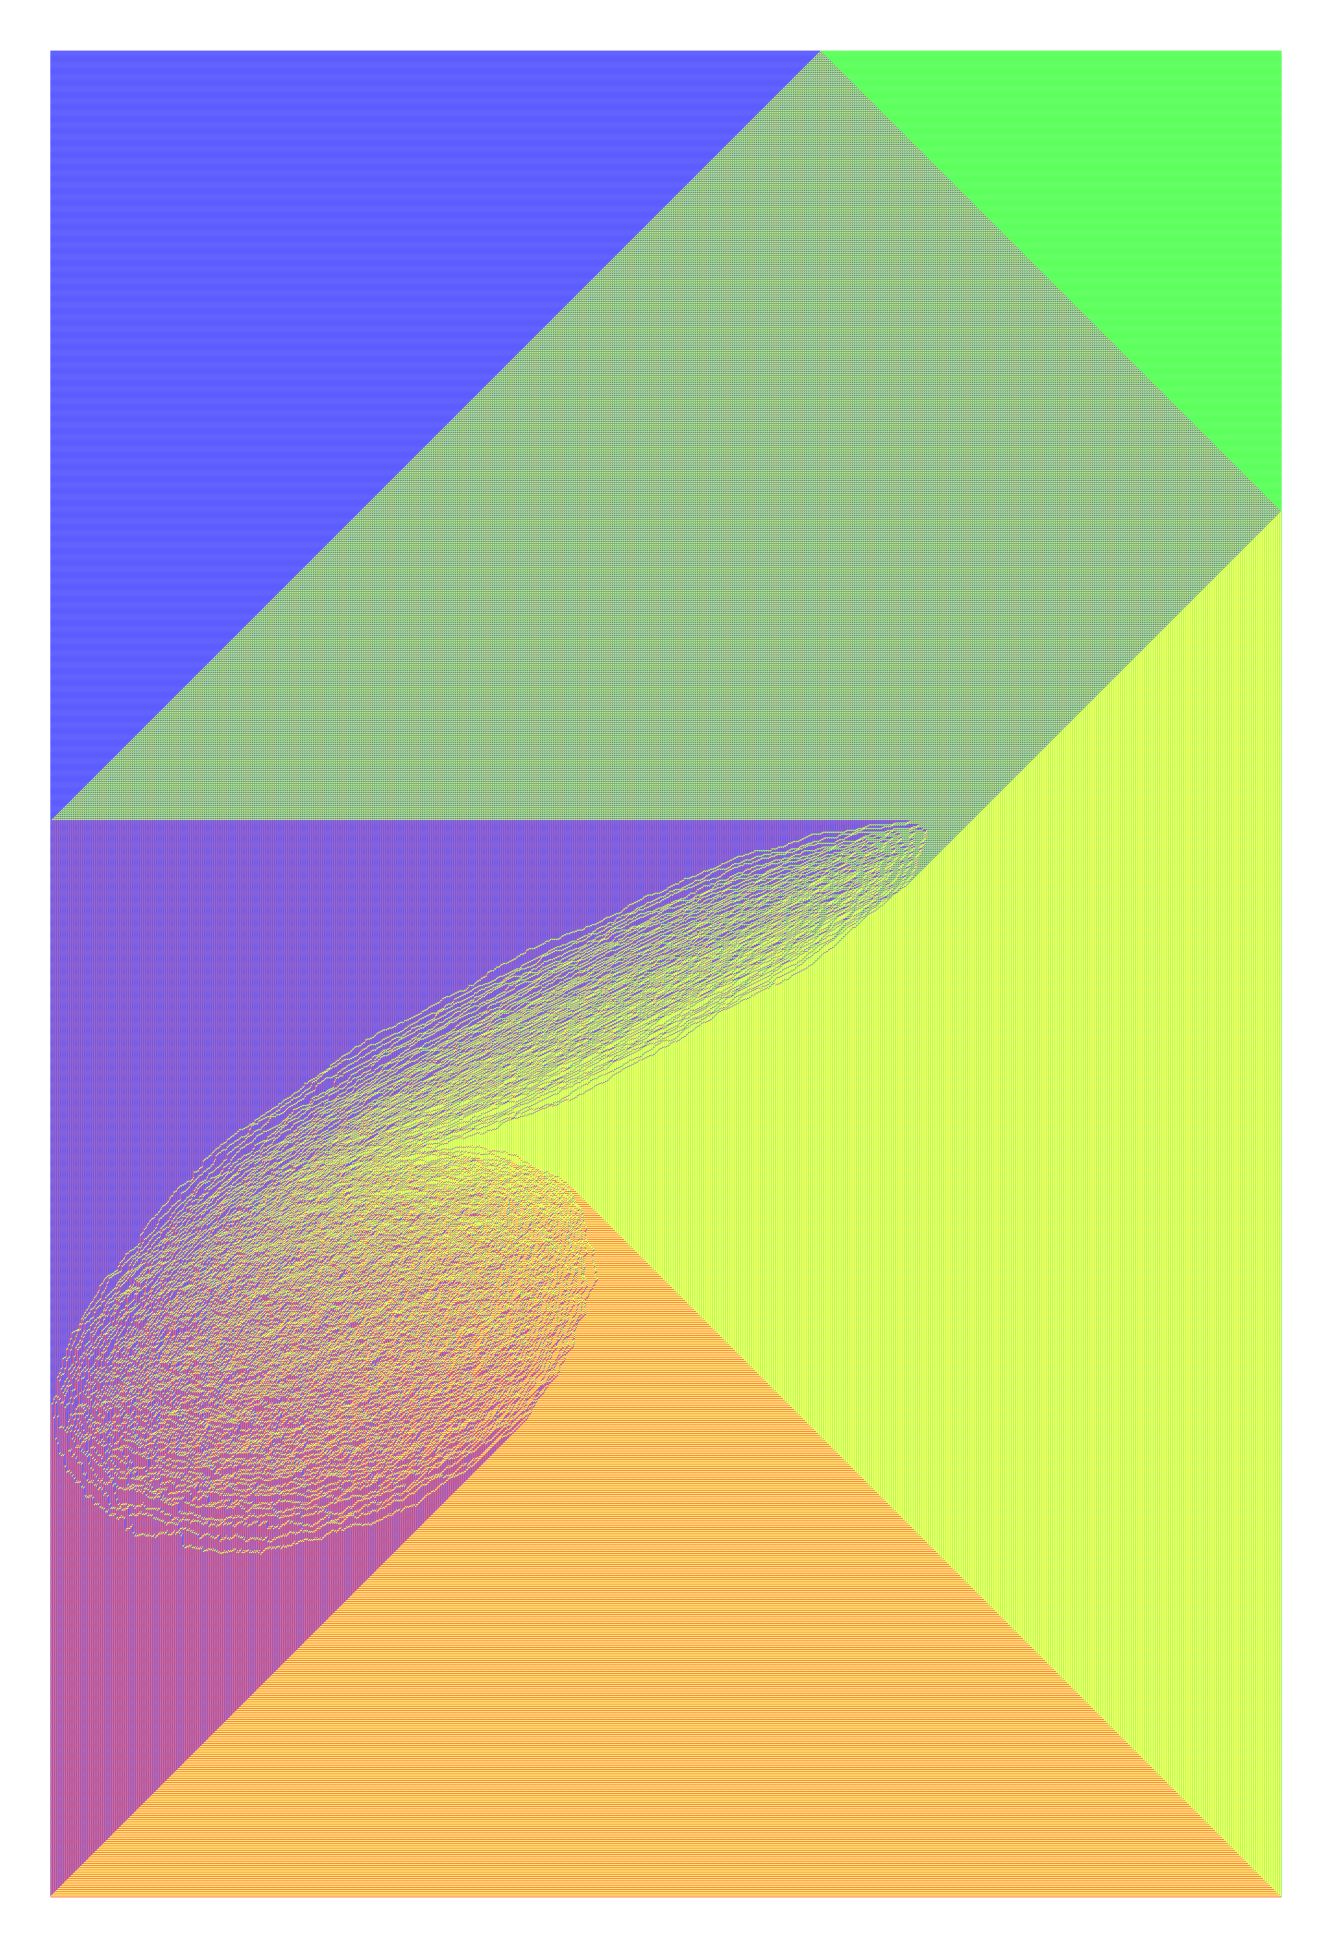

In [ ]:
n      = 2000
mp.dps = 100
r      = 2


def diff(theta,phi):
    return np.abs(np.sin((theta-phi)/2))

alpha = 0.
beta = np.pi/25
gamma = 4*np.pi/5
delta = 6*np.pi/5
epsilon = 8*np.pi/5


w = np.array([[1+1j,diff(epsilon,gamma),diff(gamma,beta),diff(delta,gamma),diff(gamma,beta),diff(beta,gamma)],
[diff(gamma,beta),diff(beta,epsilon),1+r*1j,diff(beta,delta),1+1j,1+r*1j],
[diff(delta,gamma),diff(epsilon,delta),diff(delta,beta),1+1j,diff(delta,alpha),diff(alpha,delta)],
[diff(gamma,alpha),diff(alpha,epsilon),diff(beta,alpha),diff(alpha,delta),1+r*1j,1+1j]])





vec_mpf = np.vectorize(mp.mpf)

t1 = time()
PT = comp_PTower(n,vec_mpf(w.real),w.imag)
print(time()-t1)
t1 = time()
M = shuffling(PT).astype(np.int8)
print(time()-t1)
fig = draw_AztecTMP(M,dpi=500,coloring='(255,33,33),(31,31,255),(32,255,32),(255,255,32)')